# DBScan - K-Means - Circular Data

In [ ]:
import pandas as pd
import numpy as np
import plotly.express as px
from sklearn.cluster import KMeans
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

In [ ]:
df = pd.read_csv("circular_data.csv")
df.sample(10)

,x,y,cluster
781,-129.006156,-283.750364,1
1843,234.499289,-439.263160,2
1657,-302.886595,-488.119107,2
710,-286.488919,-147.988230,1
1421,-504.827274,216.824258,2
2247,-262.000000,-408.000000,3
486,-23.228206,297.446825,1
608,-297.725084,102.444587,1
2058,297.000000,48.000000,3
1257,-72.425299,492.030215,2


In [ ]:
fig = px.scatter(df,
                    x="x",
                    y="y",
                    color="cluster",
                    height=500)
fig.show()

K-Means

In [ ]:
X = df[['x', 'y']]

kmeans = KMeans(n_clusters=3, random_state=0, n_init='auto')
kmeans.fit(X)

KMeans(n_clusters=3, random_state=0)

In [ ]:
df["predicted"] = kmeans.predict(X)
df.sample(10)

,x,y,cluster,predicted
1435,-495.424341,141.737916,2,0
285,85.916134,-22.138807,0,2
1696,-133.042397,-498.435478,2,1
663,-317.265732,-50.648336,1,0
2239,551.000000,-232.000000,3,2
1904,336.104566,-284.190540,2,2
1262,-93.693080,414.186501,2,0
243,22.285830,-113.001795,0,1
867,88.053447,-278.648696,1,1
155,-111.388282,-11.545555,0,0


In [ ]:
fig = px.scatter(df,
                    x="x",
                    y="y",
                    color="predicted",
                    height=500)
fig.show()

## DBSCAN

In [ ]:
X = df[['x', 'y']]

dbscan = DBSCAN(eps=35, min_samples=6, n_jobs=-1)
df["predicted"] = dbscan.fit_predict(X)

In [ ]:
df.sample(10)

,x,y,cluster,predicted
1578,-490.302665,-200.546028,2,2
2218,-591.000000,125.000000,3,-1
775,-152.558509,-284.407008,1,1
2018,433.000000,59.000000,3,2
2262,-461.000000,301.000000,3,2
1248,-57.975813,464.279970,2,2
1874,329.240839,-353.522008,2,2
2074,-203.000000,561.000000,3,-1
1456,-504.380329,150.774593,2,2
470,-25.675547,284.680401,1,1


In [ ]:
df.describe()

,x,y,cluster,predicted
count,2300.000000,2300.000000,2300.000000,2300.000000
mean,-18.348816,-19.560487,1.565217,1.181304
std,292.088277,290.348173,0.876253,0.932100
min,-591.000000,-612.225217,0.000000,-1.000000
25%,-262.025458,-258.142045,1.000000,1.000000
50%,-16.758860,-19.405716,2.000000,1.000000
75%,220.236096,219.137358,2.000000,2.000000
max,592.000000,596.000000,3.000000,2.000000


In [ ]:
df = df.astype({"x": int,
                "y": int,
                "cluster": "category",
                "predicted": "category"})

## Visualization

In [ ]:
fig = px.scatter(df,
                    x="x",
                    y="y",
                    color="predicted",
                    height=500)
fig.show()

## Nearest Neighbors

Now we can find Nearest Neighbors to find proper eps value.

In [ ]:
nn = NearestNeighbors(n_neighbors=2)
neighbors = nn.fit(X)
distances, indices = neighbors.kneighbors(X)
distances = np.sort(distances, axis=0)

distances

array([[  0.        ,   0.15711274],
       [  0.        ,   0.15711274],
       [  0.        ,   0.22379981],
       ...,
       [  0.        ,  87.36704184],
       [  0.        ,  90.52071586],
       [  0.        , 101.8978785 ]])

In [ ]:
# only extracting the second column since the first one is all zeros
distances = distances[:,1]
distances

array([  0.15711274,   0.15711274,   0.22379981, ...,  87.36704184,
        90.52071586, 101.8978785 ])

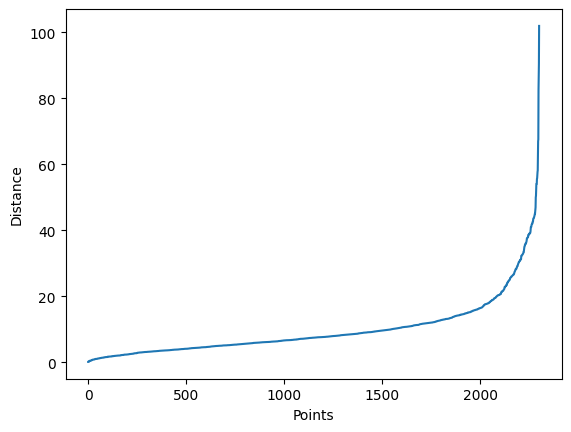

In [ ]:
sns.lineplot(x=list(range(len(distances))), y=distances)
plt.xlabel("Points")
plt.ylabel("Distance")
plt.show()